# FEB3 — Playbook 3 (Visualització i Conclusions)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1) Càrrega del dataset amb clústers (CSV final)

In [6]:
df = pd.read_csv("FEB3_players_clustered_k6.csv")

print("Files:", df.shape[0], "Columnes:", df.shape[1])
df.head()


Files: 4755 Columnes: 13


,player_feb_id,season_id,games,avg_min,avg_ast,avg_trb,avg_tov,avg_2pa,avg_3pa,fg2_pct,fg3_pct,cluster,cluster_name
0,2816298,2025,12,24.131944,1.000000,6.166667,1.833333,6.250000,5.250000,0.388757,0.387037,2,Tiradors exteriors (volum+% 3p)
1,2648564,2023-2024,26,33.455128,1.500000,8.153846,3.000000,10.961538,0.961538,0.607855,0.186275,4,Control (pèrdues baixes)
2,1384586,2025,12,27.731944,3.833333,5.250000,2.833333,4.333333,1.500000,0.395238,0.435185,1,Generadors de joc (assistències)
3,1246691,2023-2024,23,23.016667,2.739130,1.869565,2.478261,2.478261,3.521739,0.417293,0.322826,1,Generadors de joc (assistències)
4,1451287,2023-2024,13,26.937179,1.538462,6.538462,2.692308,9.384615,0.384615,0.360577,0.000000,4,Control (pèrdues baixes)


## 2) Definició de *features* i comprovacions

In [7]:
# Features utilitzades al model (han de coincidir amb Playbook 2)
features = [
    "avg_ast", "avg_trb", "avg_tov",
    "avg_2pa", "avg_3pa",
    "fg2_pct", "fg3_pct"
]

required_cols = set(features + ["cluster"])
missing = sorted(list(required_cols - set(df.columns)))
if missing:
    raise ValueError(f"Falten columnes al CSV: {missing}")

# Columnes de nom (si existeix) per fer les conclusions més llegibles
has_cluster_name = "cluster_name" in df.columns

df[features].describe().T


,count,mean,std,min,25%,50%,75%,max
avg_ast,4755.0,1.361977,1.045003,0.0,0.611111,1.090909,1.840000,9.250000
avg_trb,4755.0,3.596370,2.206159,0.0,1.956522,3.166667,4.815341,14.500000
avg_tov,4755.0,1.458678,0.783827,0.0,0.880000,1.363636,1.956522,6.000000
avg_2pa,4755.0,3.879278,2.450018,0.0,2.000000,3.520000,5.382784,15.642857
avg_3pa,4755.0,2.516181,1.991453,0.0,0.881176,2.117647,3.800000,11.250000
fg2_pct,4755.0,0.457886,0.125676,0.0,0.389424,0.464796,0.533259,1.000000
fg3_pct,4755.0,0.235297,0.133006,0.0,0.166667,0.250000,0.316173,1.000000


## 3) Taula resum per clúster (mitjanes)
Això substitueix el segon CSV: la taula es calcula **directament** a partir del dataset final.

In [8]:
cluster_summary = (
    df.groupby("cluster")[features]
    .mean()
    .round(3)
    .sort_index()
)

cluster_summary


,avg_ast,avg_trb,avg_tov,avg_2pa,avg_3pa,fg2_pct,fg3_pct
cluster,,,,,,,
0,0.650,3.149,0.998,3.101,0.590,0.507,0.054
1,3.158,4.216,2.518,5.638,4.367,0.464,0.279
2,1.521,3.267,1.537,3.681,4.225,0.439,0.288
3,0.716,1.565,0.782,1.464,1.646,0.283,0.210
4,1.361,6.983,2.007,7.150,1.696,0.520,0.216
5,0.784,2.455,0.908,2.308,1.764,0.535,0.325


## 4) Mida de cada clúster (quants jugadors per perfil)

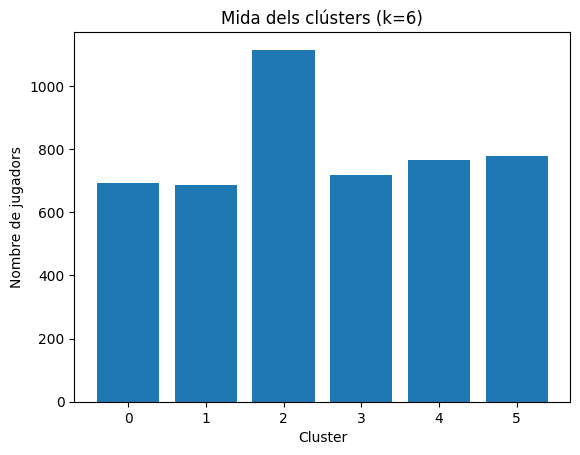

cluster
0     694
1     685
2    1115
3     717
4     767
5     777
Name: count, dtype: int64

In [9]:
cluster_sizes = df["cluster"].value_counts().sort_index()

plt.figure()
plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values)
plt.xlabel("Cluster")
plt.ylabel("Nombre de jugadors")
plt.title("Mida dels clústers (k=6)")
plt.show()

cluster_sizes


El gràfic mostra quants jugadors hi ha a cada clúster.
Els clústers tenen una mida similar, fet que indica que el model reparteix els jugadors de manera equilibrada.

## 5) Comparativa global: mitjanes per clúster (plot)


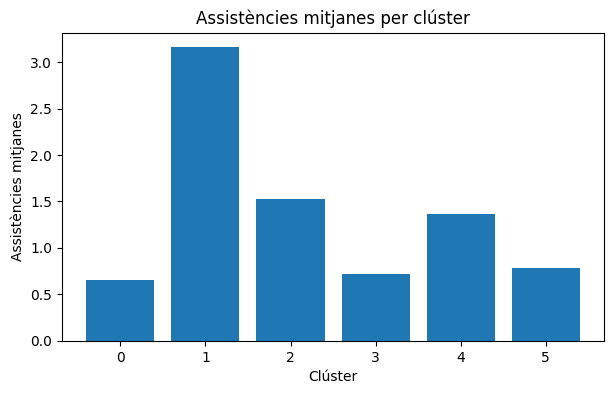

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.bar(cluster_summary.index.astype(str), cluster_summary["avg_ast"])
plt.xlabel("Clúster")
plt.ylabel("Assistències mitjanes")
plt.title("Assistències mitjanes per clúster")
plt.show()


Aquest gràfic mostra la mitjana d’assistències per clúster.
Permet identificar quins perfils tenen una major participació en la generació de joc.

## 6) Boxplots per variable (distribució dins de cada clúster)
Això és el que normalment dona més credibilitat, perquè no només mires mitjanes.

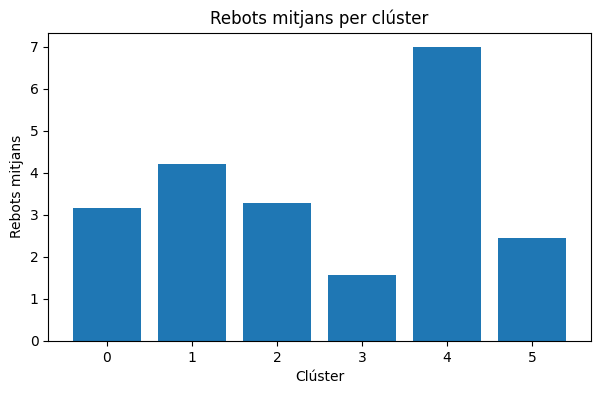

In [12]:
plt.figure(figsize=(7,4))
plt.bar(cluster_summary.index.astype(str), cluster_summary["avg_trb"])
plt.xlabel("Clúster")
plt.ylabel("Rebots mitjans")
plt.title("Rebots mitjans per clúster")
plt.show()


Aquest gràfic mostra la mitjana de rebots per clúster.
Es poden observar diferències clares entre perfils amb més presència interior i altres amb menor aportació en el rebot.

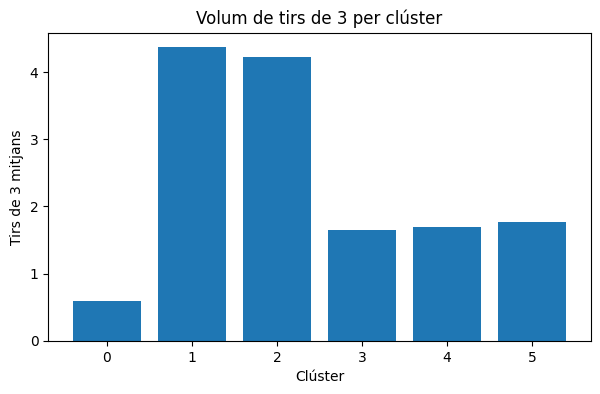

In [13]:
plt.figure(figsize=(7,4))
plt.bar(cluster_summary.index.astype(str), cluster_summary["avg_3pa"])
plt.xlabel("Clúster")
plt.ylabel("Tirs de 3 mitjans")
plt.title("Volum de tirs de 3 per clúster")
plt.show()


Aquest gràfic permet comparar l’ús del tir exterior entre els diferents clústers.

## 7) Projecció 2D amb PCA (visualització dels clústers)
PCA és una projecció lineal ràpida per veure si hi ha separació visual.

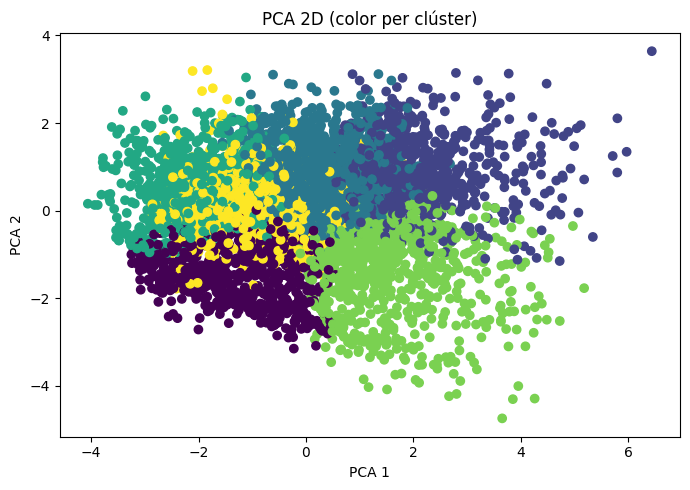

Explained variance ratio: [0.40965129 0.22019163]
Total explained variance: 0.6298429215922206


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA 2D (color per clúster)")
plt.tight_layout()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


Aquesta projecció en dues dimensions permet veure com es distribueixen els jugadors segons el clúster assignat.
Tot i que alguns grups es barregen, es poden apreciar diferències entre perfils, cosa que indica que el clustering separa jugadors amb característiques diferents.
Els dos primers components del PCA expliquen aproximadament el 63% de la informació de les dades, fet que fa adequada aquesta representació per visualitzar els resultats.

## 8) Taula final: clúster + nom



In [11]:
# Variables “clau” (triades per interpretació ràpida)
key_vars = ["avg_ast", "avg_trb", "avg_3pa"]

cols_out = ["cluster"] + (["cluster_name"] if has_cluster_name else []) + key_vars
final_table = (
    df[cols_out]
    .groupby(["cluster"] + (["cluster_name"] if has_cluster_name else []))[key_vars]
    .mean()
    .round(3)
    .reset_index()
    .sort_values("cluster")
)

final_table


,cluster,cluster_name,avg_ast,avg_trb,avg_3pa
0,0,Interiors (2p+rebots),0.650,3.149,0.590
1,1,Generadors de joc (assistències),3.158,4.216,4.367
2,2,Tiradors exteriors (volum+% 3p),1.521,3.267,4.225
3,3,Finalitzadors eficients 2p,0.716,1.565,1.646
4,4,Control (pèrdues baixes),1.361,6.983,1.696
5,5,Perfil mixt #5,0.784,2.455,1.764


En aquesta taula es pot veure cada clúster amb el seu nom i tres estadístiques clau.
Permet identificar fàcilment quin tipus de jugador representa cada perfil segons les assistències, els rebots i l’ús del tir de tres punts.

## Conclusions

En aquest playbook s’han utilitzat diferents tipus de visualitzacions per analitzar els resultats del clustering aplicat als jugadors.
A partir de les taules i els gràfics, es pot observar que els jugadors es distribueixen en diversos clústers amb característiques diferents, cosa que indica que el model ha sabut captar patrons reals a les dades.

Les gràfiques de barres i els boxplots mostren diferències clares entre clústers en variables com les assistències, els rebots i el volum de tirs de tres punts, fet que permet identificar perfils amb rols diferents dins del joc.
A més, la projecció en dues dimensions mitjançant PCA ajuda a visualitzar com es reparteixen els jugadors segons el clúster assignat, mostrant certa separació entre grups tot i que existeixi solapament, cosa habitual en dades reals.

Finalment, la taula resum amb els noms dels clústers facilita la interpretació esportiva dels resultats i permet entendre de manera senzilla quin tipus de jugador representa cada perfil.